In [85]:
from pathlib import Path
from smr_analysis_final import generate_reports, prepare_visualization_data

nc_root = Path("output/Final_Set")
bl2_folder = Path("output/Final_Set/BL2")
data_folder = Path("output/Final_Set/extracted_data")
output_folder = Path("output/Final_Set/analysis_results")

comparisons, all_data = generate_reports(nc_root, bl2_folder, data_folder, output_folder)
df_viz1, df_viz2, df_viz3, df_viz4 = prepare_visualization_data(comparisons, output_folder)



PROCESSING 14 RUNS (DEDUPLICATED + K-MEANS WEIGHTS)

EV Scenario:
    ✗ BL_EV: .nc file not found
    ✗ TO_EV: .nc file not found
    ✗ HI_EV: .nc file not found
    ✗ RR_EV: .nc file not found
    ✗ TOX_EV: .nc file not found
    ✗ HIX_EV: .nc file not found
    ✗ RRX_EV: .nc file not found

KM Scenario:
    ✗ BL_KM: .nc file not found
    ✗ TO_KM: .nc file not found
    ✗ HI_KM: .nc file not found
    ✗ RR_KM: .nc file not found
    ✗ TOX_KM: .nc file not found
    ✗ HIX_KM: .nc file not found
    ✗ RRX_KM: .nc file not found

GENERATING COMPARISON TABLES

Building EV comparison table...
  ✓ Saved: output/Final_Set/analysis_results/comparison_EV.csv

EV Preview (Demand Fulfillment %):


KeyError: "None of [Index(['Run', 'Type', 'Config', 'Capacity', 'electricity_smr_fulfillment_pct',\n       'heat_smr_fulfillment_pct', 'hydrogen_smr_fulfillment_pct'],\n      dtype='object')] are in the [columns]"

In [ ]:
from pathlib import Path
from smr_analysis_final import generate_reports, prepare_visualization_data

nc_root = Path("output/Final_Set")
bl2_folder = Path("output/Final_Set/BL2")
data_folder = Path("output/Final_Set/extracted_data")
output_folder = Path("output/Final_Set/analysis_results")

def prepare_visualization_data(comparisons, output_folder):
    """Prepare data for visualizations."""
    output_folder = Path(output_folder)
    
    print("\nPreparing visualization data...")
    
    # VIZ 1: Demand fulfillment
    viz1_rows = []
    for scenario, df_comp in comparisons.items():
        df_smr = df_comp[df_comp['Type'] == 'SMR']
        for _, row in df_smr.iterrows():
            viz1_rows.append({
                'Scenario': scenario,
                'Run': row['Run'],
                'Config': row['Config'],
                'Capacity': row['Capacity'],
                'Electricity_Fulfillment_%': row['electricity_smr_fulfillment_pct'],
                'Heat_Fulfillment_%': row['heat_smr_fulfillment_pct'],
                'Hydrogen_Fulfillment_%': row['hydrogen_smr_fulfillment_pct']
            })
    
    df_viz1 = pd.DataFrame(viz1_rows)
    viz1_csv = output_folder / "viz1_demand_fulfillment.csv"
    df_viz1.to_csv(viz1_csv, index=False)
    print(f"  ✓ VIZ1: {viz1_csv}")
    
    # VIZ 2: Cost comparison
    viz2_rows = []
    for scenario, df_comp in comparisons.items():
        for _, row in df_comp.iterrows():
            viz2_rows.append({
                'Scenario': scenario,
                'Run': row['Run'],
                'Type': row['Type'],
                'Config': row['Config'],
                'Total_Var_Cost_M€': row['total_var_cost_M€'],
                'Electricity_Cost_M€': row['var_cost_electricity_M€'],
                'Heat_Cost_M€': row['var_cost_heat_M€'],
                'Hydrogen_Cost_M€': row['var_cost_hydrogen_M€']
            })
    
    df_viz2 = pd.DataFrame(viz2_rows)
    viz2_csv = output_folder / "viz2_cost_comparison.csv"
    df_viz2.to_csv(viz2_csv, index=False)
    print(f"  ✓ VIZ2: {viz2_csv}")
    
    # VIZ 3: SMR production
    viz3_rows = []
    for scenario, df_comp in comparisons.items():
        df_smr = df_comp[df_comp['Type'] == 'SMR']
        for _, row in df_smr.iterrows():
            viz3_rows.append({
                'Scenario': scenario,
                'Run': row['Run'],
                'Config': row['Config'],
                'Capacity': row['Capacity'],
                'Electricity_Production_GWh': row.get('smr_prod_electricity_GWh', 0),
                'Heat_Production_GWh': row.get('smr_prod_heat_GWh', 0),
                'Hydrogen_Production_GWh': row.get('smr_prod_hydrogen_GWh', 0)
            })
    
    df_viz3 = pd.DataFrame(viz3_rows)
    viz3_csv = output_folder / "viz3_smr_production.csv"
    df_viz3.to_csv(viz3_csv, index=False)
    print(f"  ✓ VIZ3: {viz3_csv}")
    
    # VIZ 4: Co-generation distribution
    viz4_rows = []
    for scenario, df_comp in comparisons.items():
        df_smr = df_comp[df_comp['Type'] == 'SMR']
        for _, row in df_smr.iterrows():
            viz4_rows.append({
                'Scenario': scenario,
                'Run': row['Run'],
                'Config': row['Config'],
                'Capacity': row['Capacity'],
                'Electricity_Share_%': row.get('smr_prod_share_electricity_pct', 0),
                'Heat_Share_%': row.get('smr_prod_share_heat_pct', 0),
                'Hydrogen_Share_%': row.get('smr_prod_share_hydrogen_pct', 0)
            })
    
    df_viz4 = pd.DataFrame(viz4_rows)
    viz4_csv = output_folder / "viz4_cogeneration_distribution.csv"
    df_viz4.to_csv(viz4_csv, index=False)
    print(f"  ✓ VIZ4: {viz4_csv}")
    
    print("\n✓ All visualization data ready!")
    
    return df_viz1, df_viz2, df_viz3, df_viz4



In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the 4 visualization datasets
output_folder = Path("output/Final_Set/analysis_results")

df_viz1 = pd.read_csv(output_folder / "viz1_demand_fulfillment.csv")
df_viz2 = pd.read_csv(output_folder / "viz2_cost_comparison.csv")
df_viz3 = pd.read_csv(output_folder / "viz3_smr_production.csv")
df_viz4 = pd.read_csv(output_folder / "viz4_cogeneration_distribution.csv")

print("Data loaded successfully!")
print(f"VIZ1 shape: {df_viz1.shape}")
print(f"VIZ2 shape: {df_viz2.shape}")
print(f"VIZ3 shape: {df_viz3.shape}")
print(f"VIZ4 shape: {df_viz4.shape}")


Data loaded successfully!
VIZ1 shape: (12, 7)
VIZ2 shape: (14, 8)
VIZ3 shape: (12, 7)
VIZ4 shape: (12, 7)


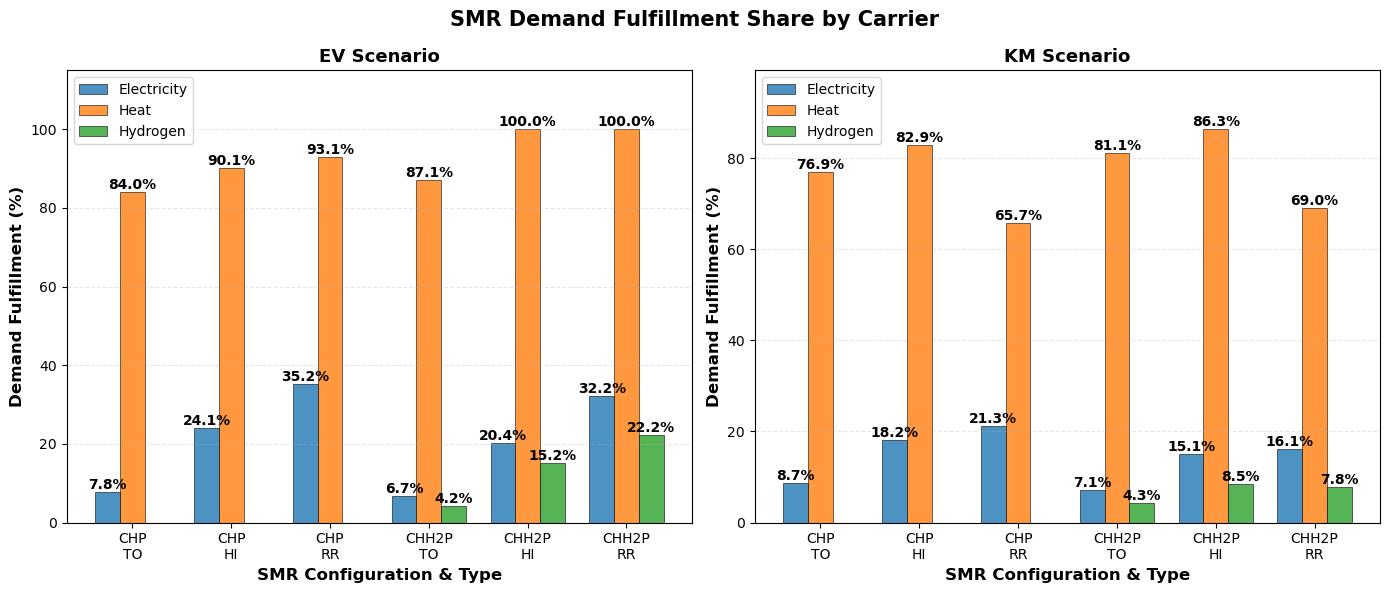

✓ VIZ1 saved


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, scenario in enumerate(['EV', 'KM']):
    ax = axes[idx]
    
    df_scenario = df_viz1[df_viz1['Scenario'] == scenario]
    
    capacity_order = ['TO', 'HI', 'RR']
    config_order = ['CHP', 'CHH2P']
    
    x_labels = []
    elec_data = []
    heat_data = []
    h2_data = []
    
    for config in config_order:
        for capacity in capacity_order:
            df_subset = df_scenario[
                (df_scenario['Config'] == config) & 
                (df_scenario['Capacity'] == capacity)
            ]
            if not df_subset.empty:
                x_labels.append(f"{config}\n{capacity}")
                elec_data.append(float(df_subset['Electricity_Fulfillment_%'].values))
                heat_data.append(float(df_subset['Heat_Fulfillment_%'].values))
                h2_data.append(float(df_subset['Hydrogen_Fulfillment_%'].values))
    
    x = np.arange(len(x_labels))
    width = 0.25
    
    bars1 = ax.bar(x - width, elec_data, width, label='Electricity', color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, heat_data, width, label='Heat', color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width, h2_data, width, label='Hydrogen', color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}%',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Demand Fulfillment (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('SMR Configuration & Type', fontsize=12, fontweight='bold')
    ax.set_title(f'{scenario} Scenario', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    max_val = max(max(elec_data), max(heat_data), max(h2_data)) if max(h2_data) > 0 else max(max(elec_data), max(heat_data))
    ax.set_ylim(0, max_val * 1.15)

plt.suptitle('SMR Demand Fulfillment Share by Carrier', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(output_folder / "VIZ1_demand_fulfillment.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ VIZ1 saved")


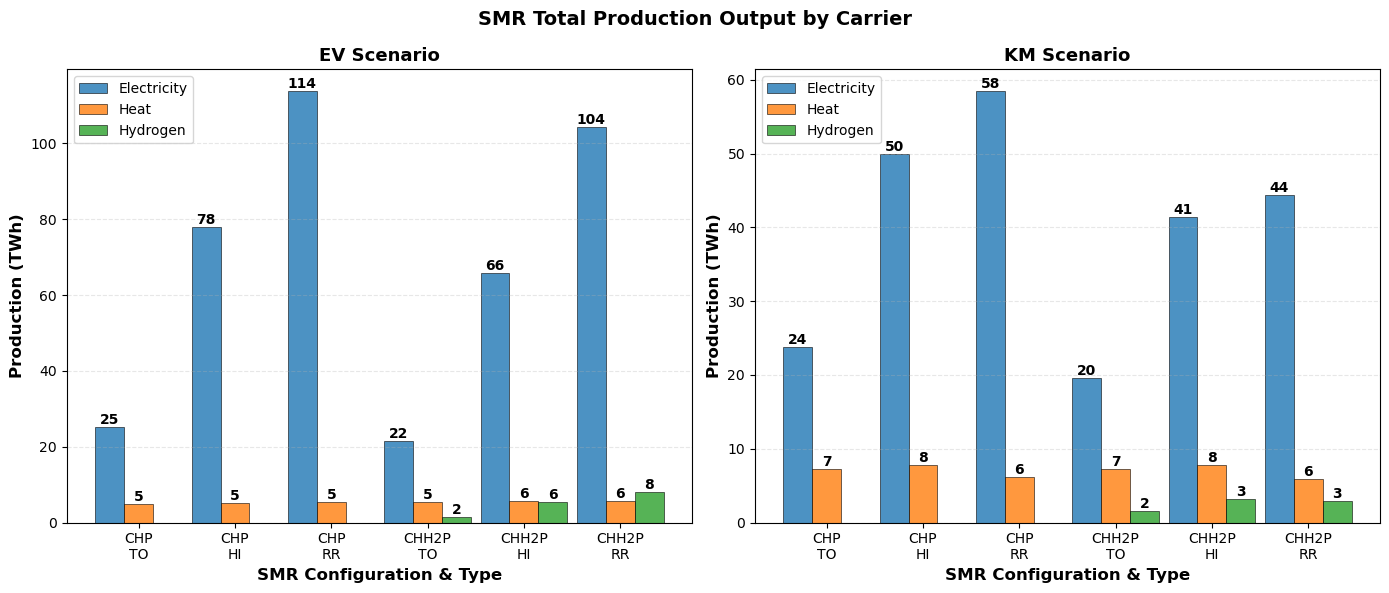

✓ VIZ3 saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, scenario in enumerate(['EV', 'KM']):
    ax = axes[idx]
    
    df_scenario = df_viz3[df_viz3['Scenario'] == scenario]
    
    
    x_labels = []
    elec_prod = []
    heat_prod = []
    h2_prod = []
    
    for config in ['CHP', 'CHH2P']:
        for capacity in ['TO', 'HI', 'RR']:
            df_subset = df_scenario[
                (df_scenario['Config'] == config) & 
                (df_scenario['Capacity'] == capacity)
            ]
            if not df_subset.empty:
                x_labels.append(f"{config}\n{capacity}")
                elec_prod.append(float(df_subset['Electricity_Production_GWh'].values))
                heat_prod.append(float(df_subset['Heat_Production_GWh'].values))
                h2_prod.append(float(df_subset['Hydrogen_Production_GWh'].values))
    
    x = np.arange(len(x_labels))
    width = 0.3
    
    bars1 = ax.bar(x - width, elec_prod, width, label='Electricity', color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, heat_prod, width, label='Heat', color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width, h2_prod, width, label='Hydrogen', color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.0f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Production (TWh)', fontsize=12, fontweight='bold')
    ax.set_xlabel('SMR Configuration & Type', fontsize=12, fontweight='bold')
    ax.set_title(f'{scenario} Scenario', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('SMR Total Production Output by Carrier', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(output_folder / "VIZ3_smr_production.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ VIZ3 saved")


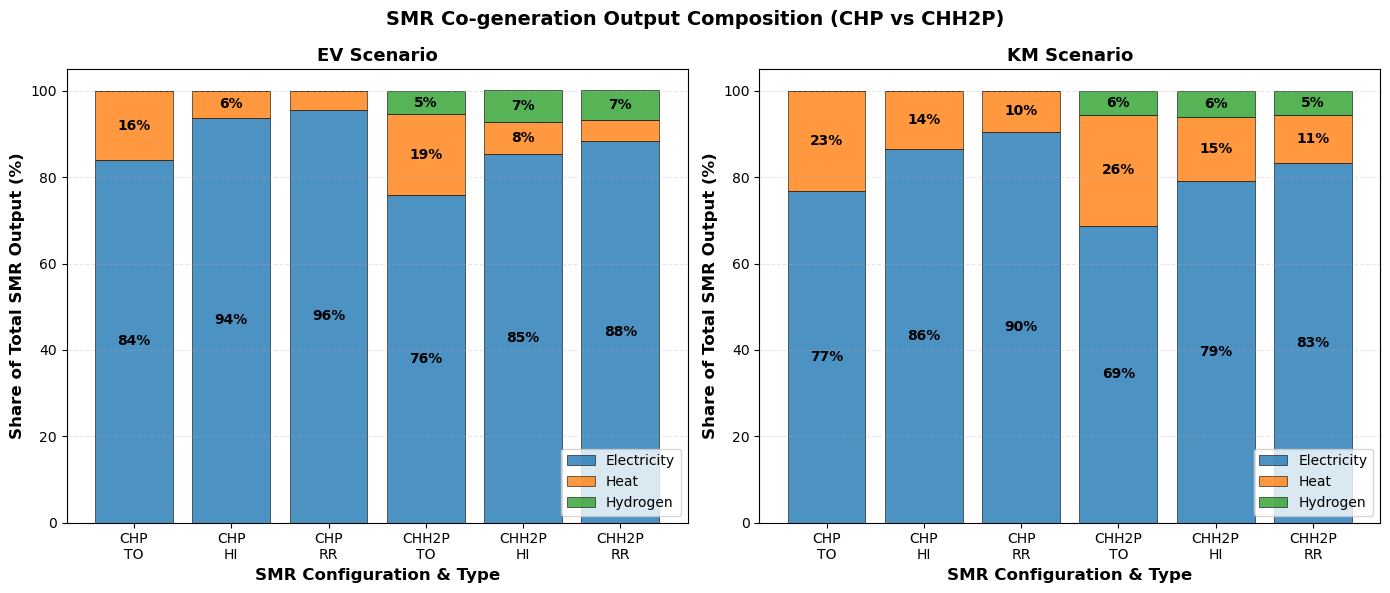

✓ VIZ4 saved


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, scenario in enumerate(['EV', 'KM']):
    ax = axes[idx]
    
    df_scenario = df_viz4[df_viz4['Scenario'] == scenario]
    
    x_labels = []
    elec_shares = []
    heat_shares = []
    h2_shares = []
    
    for config in ['CHP', 'CHH2P']:
        for capacity in ['TO', 'HI', 'RR']:
            df_subset = df_scenario[
                (df_scenario['Config'] == config) & 
                (df_scenario['Capacity'] == capacity)
            ]
            if not df_subset.empty:
                x_labels.append(f"{config}\n{capacity}")
                elec_shares.append(float(df_subset['Electricity_Share_%'].values))
                heat_shares.append(float(df_subset['Heat_Share_%'].values))
                h2_shares.append(float(df_subset['Hydrogen_Share_%'].values))
    
    x = np.arange(len(x_labels))
    
    bars1 = ax.bar(x, elec_shares, label='Electricity', color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, heat_shares, bottom=elec_shares, label='Heat', color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    h2_bottom = np.array(elec_shares) + np.array(heat_shares)
    bars3 = ax.bar(x, h2_shares, bottom=h2_bottom, label='Hydrogen', color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Add percentage labels
    for i, (e, h, hz) in enumerate(zip(elec_shares, heat_shares, h2_shares)):
        if e >= 5:
            ax.text(i, e/2, f'{e:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        if h >= 5:
            ax.text(i, e + h/2, f'{h:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        if hz >= 5:
            ax.text(i, e + h + hz/2, f'{hz:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
    
    ax.set_ylabel('Share of Total SMR Output (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('SMR Configuration & Type', fontsize=12, fontweight='bold')
    ax.set_title(f'{scenario} Scenario', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('SMR Co-generation Output Composition (CHP vs CHH2P)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(output_folder / "VIZ4_cogeneration_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ VIZ4 saved")


FOR THE REMAINING RUNS C &H

In [27]:
from pathlib import Path
from smr_analysis_flexible import generate_reports, prepare_visualization_data

# Define folder paths
nc_folder = Path("output/Final_Set")
data_folder = Path("output/Final_Set/extracted_data")
output_folder = Path("output/Final_Set/analysis_results_flexible")

# Run analysis
print("Starting SMR analysis...\n")
comparisons, all_data, runs_metadata = generate_reports(nc_folder, data_folder, output_folder)

# Prepare visualization data
print("\n" + "="*70)
viz_data = prepare_visualization_data(comparisons, output_folder)

print("\n✓ Analysis and visualization data preparation complete!")
print(f"\nResults saved to: {output_folder}")


Starting SMR analysis...


DISCOVERING RUNS

Found 41 valid runs:
  EV / C150: 5 runs
  EV / C75: 6 runs
  EV / H2: 6 runs
  EV / H5: 5 runs
  KM / C150: 5 runs
  KM / C75: 4 runs
  KM / H2: 5 runs
  KM / H5: 5 runs

PROCESSING RUNS

EV Scenario:
  C75:
  Loading HIX_C75_EV...


/home/khasselaar/Thesis/smr_analysis_flexible.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smr_dedup['weighted_prod'] = df_smr_dedup['production'] * df_smr_dedup['weight']


    ✓ HIX_C75_EV (SMR: pp_SMR_Hitachi_CHH2P_1)
  Loading HI_C75_EV...


/home/khasselaar/Thesis/smr_analysis_flexible.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smr_dedup['weighted_prod'] = df_smr_dedup['production'] * df_smr_dedup['weight']


    ✓ HI_C75_EV (SMR: pp_SMR_Hitachi_CHP_1)
  Loading RRX_C75_EV...


...

/home/khasselaar/Thesis/smr_analysis_flexible.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smr_dedup['weighted_prod'] = df_smr_dedup['production'] * df_smr_dedup['weight']


    ✓ RR_H5_KM (SMR: pp_SMR_RollsRoyce_CHP_1)
  Loading TOX_H5_KM...


/home/khasselaar/Thesis/smr_analysis_flexible.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smr_dedup['weighted_prod'] = df_smr_dedup['production'] * df_smr_dedup['weight']


    ✓ TOX_H5_KM (SMR: pp_SMR_Thorizon_CHH2P_1)
  Loading TO_H5_KM...
    ✓ TO_H5_KM (SMR: pp_SMR_Thorizon_CHP_1)

GENERATING COMPARISON TABLES

EV Scenario:
  ✓ C75: output/Final_Set/analysis_results_flexible/EV/comparison_C75.csv (6 runs)
    Preview (Demand Fulfillment %):
       Run SMR_Type Config  electricity_smr_fulfillment_pct  heat_smr_fulfillment_pct  hydrogen_smr_fulfillment_pct
HIX_C75_EV       HI  CHH2P                            20.47                     99.26                         14.38
 HI_C75_EV       HI    CHP                            23.60                     89.78                          0.00
RRX_C75_EV       RR  CHH2P                            32.31                    100.10                         23.44
 RR_C75_EV       RR    CHP                            38.50                     94.03                          0.00
TOX_C75_EV       TO  CHH2P                             6.67                     87.07                          4.21
 TO_C75_EV       TO    CHP  

/home/khasselaar/Thesis/smr_analysis_flexible.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_smr_dedup['weighted_prod'] = df_smr_dedup['production'] * df_smr_dedup['weight']


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

output_folder = Path("output/Final_Set/analysis_results_flexible")


df_viz1_ev_c75 = pd.read_csv(output_folder / "EV" / "viz1_demand_fulfillment_C75.csv")
df_viz1_ev_c150 = pd.read_csv(output_folder / "EV" / "viz1_demand_fulfillment_C150.csv")
df_viz1_ev_h2 = pd.read_csv(output_folder / "EV" / "viz1_demand_fulfillment_H2.csv")
df_viz1_ev_h5 = pd.read_csv(output_folder / "EV" / "viz1_demand_fulfillment_H5.csv")

df_viz1_km_c75 = pd.read_csv(output_folder / "KM" / "viz1_demand_fulfillment_C75.csv")
df_viz1_km_c150 = pd.read_csv(output_folder / "KM" / "viz1_demand_fulfillment_C150.csv")
df_viz1_km_h2 = pd.read_csv(output_folder / "KM" / "viz1_demand_fulfillment_H2.csv")
df_viz1_km_h5 = pd.read_csv(output_folder / "KM" / "viz1_demand_fulfillment_H5.csv")


df_viz2_ev_c75 = pd.read_csv(output_folder / "EV" / "viz2_smr_production_C75.csv")
df_viz2_ev_c150 = pd.read_csv(output_folder / "EV" / "viz2_smr_production_C150.csv")
df_viz2_ev_h2 = pd.read_csv(output_folder / "EV" / "viz2_smr_production_H2.csv")
df_viz2_ev_h5 = pd.read_csv(output_folder / "EV" / "viz2_smr_production_H5.csv")

df_viz2_km_c75 = pd.read_csv(output_folder / "KM" / "viz2_smr_production_C75.csv")
df_viz2_km_c150 = pd.read_csv(output_folder / "KM" / "viz2_smr_production_C150.csv")
df_viz2_km_h2 = pd.read_csv(output_folder / "KM" / "viz2_smr_production_H2.csv")
df_viz2_km_h5 = pd.read_csv(output_folder / "KM" / "viz2_smr_production_H5.csv")


df_viz3_ev_c75 = pd.read_csv(output_folder / "EV" / "viz3_cogeneration_distribution_C75.csv")
df_viz3_ev_c150 = pd.read_csv(output_folder / "EV" / "viz3_cogeneration_distribution_C150.csv")
df_viz3_ev_h2 = pd.read_csv(output_folder / "EV" / "viz3_cogeneration_distribution_H2.csv")
df_viz3_ev_h5 = pd.read_csv(output_folder / "EV" / "viz3_cogeneration_distribution_H5.csv")

df_viz3_km_c75 = pd.read_csv(output_folder / "KM" / "viz3_cogeneration_distribution_C75.csv")
df_viz3_km_c150 = pd.read_csv(output_folder / "KM" / "viz3_cogeneration_distribution_C150.csv")
df_viz3_km_h2 = pd.read_csv(output_folder / "KM" / "viz3_cogeneration_distribution_H2.csv")
df_viz3_km_h5 = pd.read_csv(output_folder / "KM" / "viz3_cogeneration_distribution_H5.csv")

print("Data loaded successfully!")
print(f"\nEV Scenario - C75 shape: {df_viz1_ev_c75.shape}")
print(f"EV Scenario - C150 shape: {df_viz1_ev_c150.shape}")
print(f"EV Scenario - H2 shape: {df_viz1_ev_h2.shape}")
print(f"EV Scenario - H5 shape: {df_viz1_ev_h5.shape}")
print(f"\nKM Scenario - C75 shape: {df_viz1_km_c75.shape}")
print(f"KM Scenario - C150 shape: {df_viz1_km_c150.shape}")
print(f"KM Scenario - H2 shape: {df_viz1_km_h2.shape}")
print(f"KM Scenario - H5 shape: {df_viz1_km_h5.shape}")

Data loaded successfully!

EV Scenario - C75 shape: (6, 6)
EV Scenario - C150 shape: (5, 6)
EV Scenario - H2 shape: (5, 6)
EV Scenario - H5 shape: (5, 6)

KM Scenario - C75 shape: (4, 6)
KM Scenario - C150 shape: (5, 6)
KM Scenario - H2 shape: (5, 6)
KM Scenario - H5 shape: (5, 6)


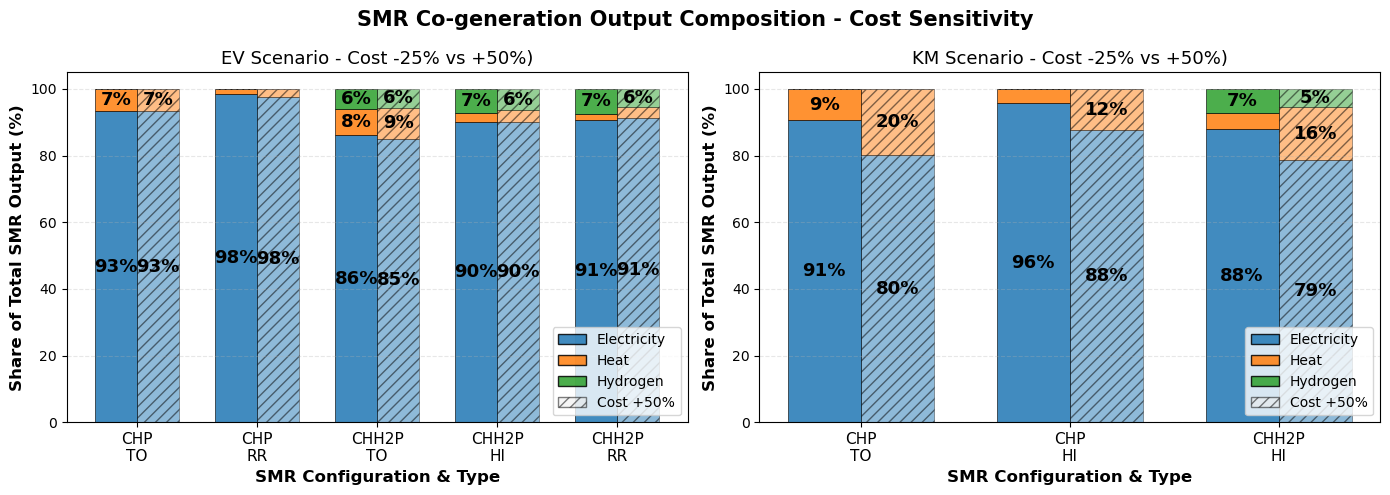

✓ VIZ3 Co-generation Cost Sensitivity saved


In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

output_folder = Path("output/Final_Set/analysis_results_flexible")

# Load data
df_viz3_ev_c75 = pd.read_csv(output_folder / "EV" / "viz3_cogeneration_distribution_C75.csv")
df_viz3_ev_c150 = pd.read_csv(output_folder / "EV" / "viz3_cogeneration_distribution_C150.csv")
df_viz3_km_c75 = pd.read_csv(output_folder / "KM" / "viz3_cogeneration_distribution_C75.csv")
df_viz3_km_c150 = pd.read_csv(output_folder / "KM" / "viz3_cogeneration_distribution_C150.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scenario_idx, scenario in enumerate(['EV', 'KM']):
    ax = axes[scenario_idx]
    
    if scenario == 'EV':
        df_c75 = df_viz3_ev_c75
        df_c150 = df_viz3_ev_c150
    else:
        df_c75 = df_viz3_km_c75
        df_c150 = df_viz3_km_c150
    
    config_order = ['CHP', 'CHH2P']
    smr_type_order = ['TO', 'HI', 'RR']
    
    x_labels = []
    elec_c75 = []
    heat_c75 = []
    h2_c75 = []
    elec_c150 = []
    heat_c150 = []
    h2_c150 = []
    
    for config in config_order:
        for smr_type in smr_type_order:
            df_subset_c75 = df_c75[
                (df_c75['Config'] == config) & 
                (df_c75['SMR_Type'] == smr_type)
            ]
            df_subset_c150 = df_c150[
                (df_c150['Config'] == config) & 
                (df_c150['SMR_Type'] == smr_type)
            ]
            
            if not df_subset_c75.empty and not df_subset_c150.empty:
                x_labels.append(f"{config}\n{smr_type}")
                elec_c75.append(float(df_subset_c75['Electricity_Share_%'].values[0]))
                heat_c75.append(float(df_subset_c75['Heat_Share_%'].values[0]))
                h2_c75.append(float(df_subset_c75['Hydrogen_Share_%'].values[0]))
                
                elec_c150.append(float(df_subset_c150['Electricity_Share_%'].values[0]))
                heat_c150.append(float(df_subset_c150['Heat_Share_%'].values[0]))
                h2_c150.append(float(df_subset_c150['Hydrogen_Share_%'].values[0]))
    
    x = np.arange(len(x_labels))
    width = 0.35
    
    # C75 stacked bars
    bars1_c75 = ax.bar(x - width/2, elec_c75, width, label='Electricity (C75)',
                       color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.5)
    bars2_c75 = ax.bar(x - width/2, heat_c75, width, bottom=elec_c75,
                       label='Heat (C75)', color='#ff7f0e', alpha=0.85, edgecolor='black', linewidth=0.5)
    
    bottom_c75 = np.array(elec_c75) + np.array(heat_c75)
    bars3_c75 = ax.bar(x - width/2, h2_c75, width, bottom=bottom_c75,
                       label='Hydrogen (C75)', color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.5)
    
    # C150 stacked bars
    bars1_c150 = ax.bar(x + width/2, elec_c150, width, label='Electricity (C150)',
                        color='#1f77b4', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    bars2_c150 = ax.bar(x + width/2, heat_c150, width, bottom=elec_c150,
                        label='Heat (C150)', color='#ff7f0e', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    
    bottom_c150 = np.array(elec_c150) + np.array(heat_c150)
    bars3_c150 = ax.bar(x + width/2, h2_c150, width, bottom=bottom_c150,
                        label='Hydrogen (C150)', color='#2ca02c', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    
    # Add text labels
    for i, (e75, h75, hz75, e150, h150, hz150) in enumerate(zip(elec_c75, heat_c75, h2_c75, elec_c150, heat_c150, h2_c150)):
        if e75 >= 5:
            ax.text(i - width/2, e75/2, f'{e75:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold')
        if h75 >= 5:
            ax.text(i - width/2, e75 + h75/2, f'{h75:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold')
        if hz75 >= 5:
            ax.text(i - width/2, e75 + h75 + hz75/2, f'{hz75:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold')
        
        if e150 >= 5:
            ax.text(i + width/2, e150/2, f'{e150:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold', color='black')
        if h150 >= 5:
            ax.text(i + width/2, e150 + h150/2, f'{h150:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold', color='black')
        if hz150 >= 5:
            ax.text(i + width/2, e150 + h150 + hz150/2, f'{hz150:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold', color='black')
    
    ax.set_ylabel('Share of Total SMR Output (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('SMR Configuration & Type', fontsize=12, fontweight='bold')
    ax.set_title(f'{scenario} Scenario - Cost -25% vs +50%)', fontsize=13, fontweight='light')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.85, edgecolor='black', label='Electricity'),
        Patch(facecolor='#ff7f0e', alpha=0.85, edgecolor='black', label='Heat'),
        Patch(facecolor='#2ca02c', alpha=0.85, edgecolor='black', label='Hydrogen'),
        Patch(facecolor="#ececec", alpha=0.5, edgecolor='black', hatch='///', label='Cost +50%'),
    ]
    ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

plt.suptitle('SMR Co-generation Output Composition - Cost Sensitivity', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(output_folder / "VIZ3_cogeneration_cost_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ VIZ3 Co-generation Cost Sensitivity saved")


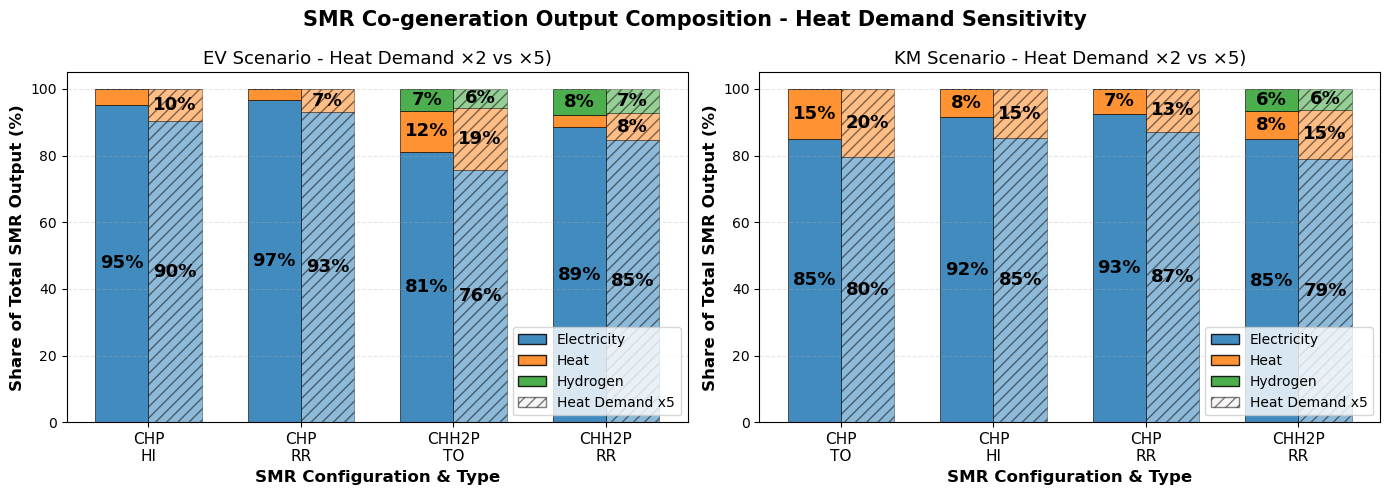

✓ VIZ3 Co-generation Heat Sensitivity saved


In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

output_folder = Path("output/Final_Set/analysis_results_flexible")

# Load data
df_viz3_ev_h2 = pd.read_csv(output_folder / "EV" / "viz3_cogeneration_distribution_H2.csv")
df_viz3_ev_h5 = pd.read_csv(output_folder / "EV" / "viz3_cogeneration_distribution_H5.csv")
df_viz3_km_h2 = pd.read_csv(output_folder / "KM" / "viz3_cogeneration_distribution_H2.csv")
df_viz3_km_h5 = pd.read_csv(output_folder / "KM" / "viz3_cogeneration_distribution_H5.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scenario_idx, scenario in enumerate(['EV', 'KM']):
    ax = axes[scenario_idx]
    
    if scenario == 'EV':
        df_h2 = df_viz3_ev_h2
        df_h5 = df_viz3_ev_h5
    else:
        df_h2 = df_viz3_km_h2
        df_h5 = df_viz3_km_h5
    
    config_order = ['CHP', 'CHH2P']
    smr_type_order = ['TO', 'HI', 'RR']
    
    x_labels = []
    elec_h2 = []
    heat_h2 = []
    h2_h2 = []
    elec_h5 = []
    heat_h5 = []
    h2_h5 = []
    
    for config in config_order:
        for smr_type in smr_type_order:
            df_subset_h2 = df_h2[
                (df_h2['Config'] == config) & 
                (df_h2['SMR_Type'] == smr_type)
            ]
            df_subset_h5 = df_h5[
                (df_h5['Config'] == config) & 
                (df_h5['SMR_Type'] == smr_type)
            ]
            
            if not df_subset_h2.empty and not df_subset_h5.empty:
                x_labels.append(f"{config}\n{smr_type}")
                elec_h2.append(float(df_subset_h2['Electricity_Share_%'].values[0]))
                heat_h2.append(float(df_subset_h2['Heat_Share_%'].values[0]))
                h2_h2.append(float(df_subset_h2['Hydrogen_Share_%'].values[0]))
                
                elec_h5.append(float(df_subset_h5['Electricity_Share_%'].values[0]))
                heat_h5.append(float(df_subset_h5['Heat_Share_%'].values[0]))
                h2_h5.append(float(df_subset_h5['Hydrogen_Share_%'].values[0]))
    
    x = np.arange(len(x_labels))
    width = 0.35
    
    # H2 stacked bars
    bars1_h2 = ax.bar(x - width/2, elec_h2, width, label='Electricity (H2)',
                      color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.5)
    bars2_h2 = ax.bar(x - width/2, heat_h2, width, bottom=elec_h2,
                      label='Heat (H2)', color='#ff7f0e', alpha=0.85, edgecolor='black', linewidth=0.5)
    
    bottom_h2 = np.array(elec_h2) + np.array(heat_h2)
    bars3_h2 = ax.bar(x - width/2, h2_h2, width, bottom=bottom_h2,
                      label='Hydrogen (H2)', color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.5)
    
    # H5 stacked bars
    bars1_h5 = ax.bar(x + width/2, elec_h5, width, label='Electricity (H5)',
                      color='#1f77b4', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    bars2_h5 = ax.bar(x + width/2, heat_h5, width, bottom=elec_h5,
                      label='Heat (H5)', color='#ff7f0e', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    
    bottom_h5 = np.array(elec_h5) + np.array(heat_h5)
    bars3_h5 = ax.bar(x + width/2, h2_h5, width, bottom=bottom_h5,
                      label='Hydrogen (H5)', color='#2ca02c', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    
    # Add text labels
    for i, (e_h2, ht_h2, hz_h2, e_h5, ht_h5, hz_h5) in enumerate(zip(elec_h2, heat_h2, h2_h2, elec_h5, heat_h5, h2_h5)):
        if e_h2 >= 5:
            ax.text(i - width/2, e_h2/2, f'{e_h2:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold')
        if ht_h2 >= 5:
            ax.text(i - width/2, e_h2 + ht_h2/2, f'{ht_h2:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold')
        if hz_h2 >= 5:
            ax.text(i - width/2, e_h2 + ht_h2 + hz_h2/2, f'{hz_h2:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold')
        
        if e_h5 >= 5:
            ax.text(i + width/2, e_h5/2, f'{e_h5:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold', color='black')
        if ht_h5 >= 5:
            ax.text(i + width/2, e_h5 + ht_h5/2, f'{ht_h5:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold', color='black')
        if hz_h5 >= 5:
            ax.text(i + width/2, e_h5 + ht_h5 + hz_h5/2, f'{hz_h5:.0f}%', ha='center', va='center', fontsize=13, fontweight='bold', color='black')
    
    ax.set_ylabel('Share of Total SMR Output (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('SMR Configuration & Type', fontsize=12, fontweight='bold')
    ax.set_title(f'{scenario} Scenario - Heat Demand ×2 vs ×5)', fontsize=13, fontweight='light')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.85, edgecolor='black', label='Electricity'),
        Patch(facecolor='#ff7f0e', alpha=0.85, edgecolor='black', label='Heat'),
        Patch(facecolor='#2ca02c', alpha=0.85, edgecolor='black', label='Hydrogen'),
        Patch(facecolor="#f0ecec", alpha=0.5, edgecolor='black', hatch='///', label='Heat Demand x5'),

    ]
    ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

plt.suptitle('SMR Co-generation Output Composition - Heat Demand Sensitivity', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(output_folder / "VIZ3_cogeneration_heat_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ VIZ3 Co-generation Heat Sensitivity saved")


COGEN absolute values GWh

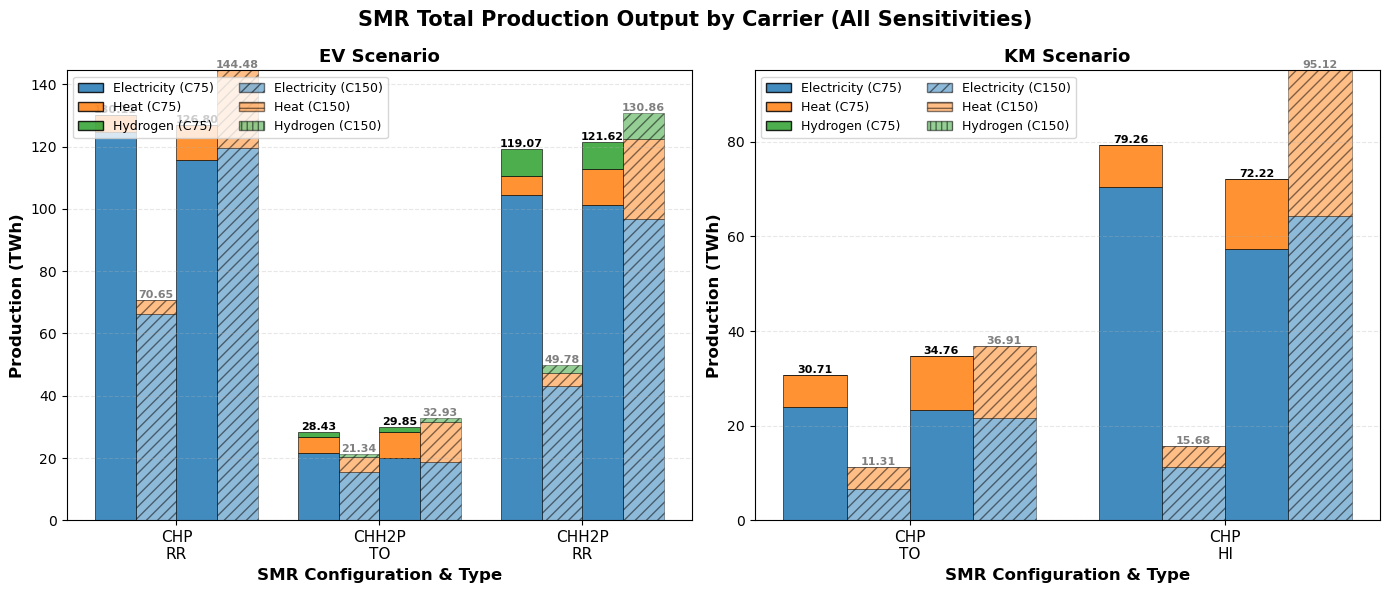

✓ VIZ2 Production (Combined Sensitivities) saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

output_folder = Path("output/Final_Set/analysis_results_flexible")

# Load data
df_viz2_ev_c75 = pd.read_csv(output_folder / "EV" / "viz2_smr_production_C75.csv")
df_viz2_ev_c150 = pd.read_csv(output_folder / "EV" / "viz2_smr_production_C150.csv")
df_viz2_ev_h2 = pd.read_csv(output_folder / "EV" / "viz2_smr_production_H2.csv")
df_viz2_ev_h5 = pd.read_csv(output_folder / "EV" / "viz2_smr_production_H5.csv")

df_viz2_km_c75 = pd.read_csv(output_folder / "KM" / "viz2_smr_production_C75.csv")
df_viz2_km_c150 = pd.read_csv(output_folder / "KM" / "viz2_smr_production_C150.csv")
df_viz2_km_h2 = pd.read_csv(output_folder / "KM" / "viz2_smr_production_H2.csv")
df_viz2_km_h5 = pd.read_csv(output_folder / "KM" / "viz2_smr_production_H5.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for scenario_idx, scenario in enumerate(['EV', 'KM']):
    ax = axes[scenario_idx]
    
    # Load appropriate data
    if scenario == 'EV':
        df_c75 = df_viz2_ev_c75
        df_c150 = df_viz2_ev_c150
        df_h2 = df_viz2_ev_h2
        df_h5 = df_viz2_ev_h5
    else:
        df_c75 = df_viz2_km_c75
        df_c150 = df_viz2_km_c150
        df_h2 = df_viz2_km_h2
        df_h5 = df_viz2_km_h5
    
    config_order = ['CHP', 'CHH2P']
    smr_type_order = ['TO', 'HI', 'RR']
    
    x_labels = []
    
    # Storage for all 4 sensitivities × 3 carriers
    elec_c75_list = []
    heat_c75_list = []
    h2_c75_list = []
    
    elec_c150_list = []
    heat_c150_list = []
    h2_c150_list = []
    
    elec_h2_list = []
    heat_h2_list = []
    h2_h2_list = []
    
    elec_h5_list = []
    heat_h5_list = []
    h2_h5_list = []
    
    for config in config_order:
        for smr_type in smr_type_order:
            df_subset_c75 = df_c75[(df_c75['Config'] == config) & (df_c75['SMR_Type'] == smr_type)]
            df_subset_c150 = df_c150[(df_c150['Config'] == config) & (df_c150['SMR_Type'] == smr_type)]
            df_subset_h2 = df_h2[(df_h2['Config'] == config) & (df_h2['SMR_Type'] == smr_type)]
            df_subset_h5 = df_h5[(df_h5['Config'] == config) & (df_h5['SMR_Type'] == smr_type)]
            
            if not df_subset_c75.empty and not df_subset_c150.empty and not df_subset_h2.empty and not df_subset_h5.empty:
                x_labels.append(f"{config}\n{smr_type}")
                
                # C75 (convert GWh to TWh)
                elec_c75_list.append(float(df_subset_c75['Electricity_Production_GWh'].values[0]) / 1000)
                heat_c75_list.append(float(df_subset_c75['Heat_Production_GWh'].values[0]) / 1000)
                h2_c75_list.append(float(df_subset_c75['Hydrogen_Production_GWh'].values[0]) / 1000)
                
                # C150
                elec_c150_list.append(float(df_subset_c150['Electricity_Production_GWh'].values[0]) / 1000)
                heat_c150_list.append(float(df_subset_c150['Heat_Production_GWh'].values[0]) / 1000)
                h2_c150_list.append(float(df_subset_c150['Hydrogen_Production_GWh'].values[0]) / 1000)
                
                # H2
                elec_h2_list.append(float(df_subset_h2['Electricity_Production_GWh'].values[0]) / 1000)
                heat_h2_list.append(float(df_subset_h2['Heat_Production_GWh'].values[0]) / 1000)
                h2_h2_list.append(float(df_subset_h2['Hydrogen_Production_GWh'].values[0]) / 1000)
                
                # H5
                elec_h5_list.append(float(df_subset_h5['Electricity_Production_GWh'].values[0]) / 1000)
                heat_h5_list.append(float(df_subset_h5['Heat_Production_GWh'].values[0]) / 1000)
                h2_h5_list.append(float(df_subset_h5['Hydrogen_Production_GWh'].values[0]) / 1000)
    
    x = np.arange(len(x_labels))
    width = 0.2  # Width for 4 bars per group
    
    # Plot C75 (stacked: electricity, heat, hydrogen)
    bars_c75_e = ax.bar(x - 1.5*width, elec_c75_list, width, label='Electricity (C75)', 
                        color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.5)
    bars_c75_h = ax.bar(x - 1.5*width, heat_c75_list, width, bottom=elec_c75_list,
                        color='#ff7f0e', alpha=0.85, edgecolor='black', linewidth=0.5)
    bottom_c75 = np.array(elec_c75_list) + np.array(heat_c75_list)
    bars_c75_hz = ax.bar(x - 1.5*width, h2_c75_list, width, bottom=bottom_c75,
                         color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.5)
    
    # Plot C150 (stacked)
    bars_c150_e = ax.bar(x - 0.5*width, elec_c150_list, width, label='Electricity (C150)',
                         color='#1f77b4', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    bars_c150_h = ax.bar(x - 0.5*width, heat_c150_list, width, bottom=elec_c150_list,
                         color='#ff7f0e', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    bottom_c150 = np.array(elec_c150_list) + np.array(heat_c150_list)
    bars_c150_hz = ax.bar(x - 0.5*width, h2_c150_list, width, bottom=bottom_c150,
                          color='#2ca02c', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    
    # Plot H2 (stacked)
    bars_h2_e = ax.bar(x + 0.5*width, elec_h2_list, width, label='Electricity (H2)',
                       color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.5)
    bars_h2_h = ax.bar(x + 0.5*width, heat_h2_list, width, bottom=elec_h2_list,
                       color='#ff7f0e', alpha=0.85, edgecolor='black', linewidth=0.5)
    bottom_h2 = np.array(elec_h2_list) + np.array(heat_h2_list)
    bars_h2_hz = ax.bar(x + 0.5*width, h2_h2_list, width, bottom=bottom_h2,
                        color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.5)
    
    # Plot H5 (stacked)
    bars_h5_e = ax.bar(x + 1.5*width, elec_h5_list, width, label='Electricity (H5)',
                       color='#1f77b4', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    bars_h5_h = ax.bar(x + 1.5*width, heat_h5_list, width, bottom=elec_h5_list,
                       color='#ff7f0e', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    bottom_h5 = np.array(elec_h5_list) + np.array(heat_h5_list)
    bars_h5_hz = ax.bar(x + 1.5*width, h2_h5_list, width, bottom=bottom_h5,
                        color='#2ca02c', alpha=0.5, edgecolor='black', linewidth=0.5, hatch='///')
    
    # Add value labels on top of each stacked bar
    for i, (ec75, hc75, hzc75, ec150, hc150, hzc150, eh2, hh2, hzh2, eh5, hh5, hzh5) in enumerate(
        zip(elec_c75_list, heat_c75_list, h2_c75_list, elec_c150_list, heat_c150_list, h2_c150_list,
            elec_h2_list, heat_h2_list, h2_h2_list, elec_h5_list, heat_h5_list, h2_h5_list)):
        
        # C75 total on top
        total_c75 = ec75 + hc75 + hzc75
        if total_c75 > 0:
            ax.text(i - 1.5*width, total_c75, f'{total_c75:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        # C150 total on top
        total_c150 = ec150 + hc150 + hzc150
        if total_c150 > 0:
            ax.text(i - 0.5*width, total_c150, f'{total_c150:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='gray')
        
        # H2 total on top
        total_h2 = eh2 + hh2 + hzh2
        if total_h2 > 0:
            ax.text(i + 0.5*width, total_h2, f'{total_h2:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        # H5 total on top
        total_h5 = eh5 + hh5 + hzh5
        if total_h5 > 0:
            ax.text(i + 1.5*width, total_h5, f'{total_h5:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='gray')
    
    ax.set_ylabel('Production (TWh)', fontsize=12, fontweight='bold')
    ax.set_xlabel('SMR Configuration & Type', fontsize=12, fontweight='bold')
    ax.set_title(f'{scenario} Scenario', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.85, edgecolor='black', label='Electricity (C75)'),
        Patch(facecolor='#ff7f0e', alpha=0.85, edgecolor='black', label='Heat (C75)'),
        Patch(facecolor='#2ca02c', alpha=0.85, edgecolor='black', label='Hydrogen (C75)'),
        Patch(facecolor="#dddddd", alpha=0.5, edgecolor='black', hatch='///', label='Electricity (C150)'),
        Patch(facecolor="#ece8e8", alpha=0.5, edgecolor='black', hatch= '---', label='Heat (C150)'),
        Patch(facecolor="#e0dcdc", alpha=0.5, edgecolor='black', hatch='|||', label='Hydrogen (C150)'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='upper left', ncol=2)

plt.suptitle('SMR Total Production Output by Carrier (All Sensitivities)', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(output_folder / "VIZ2_production_combined_sensitivities.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ VIZ2 Production (Combined Sensitivities) saved")


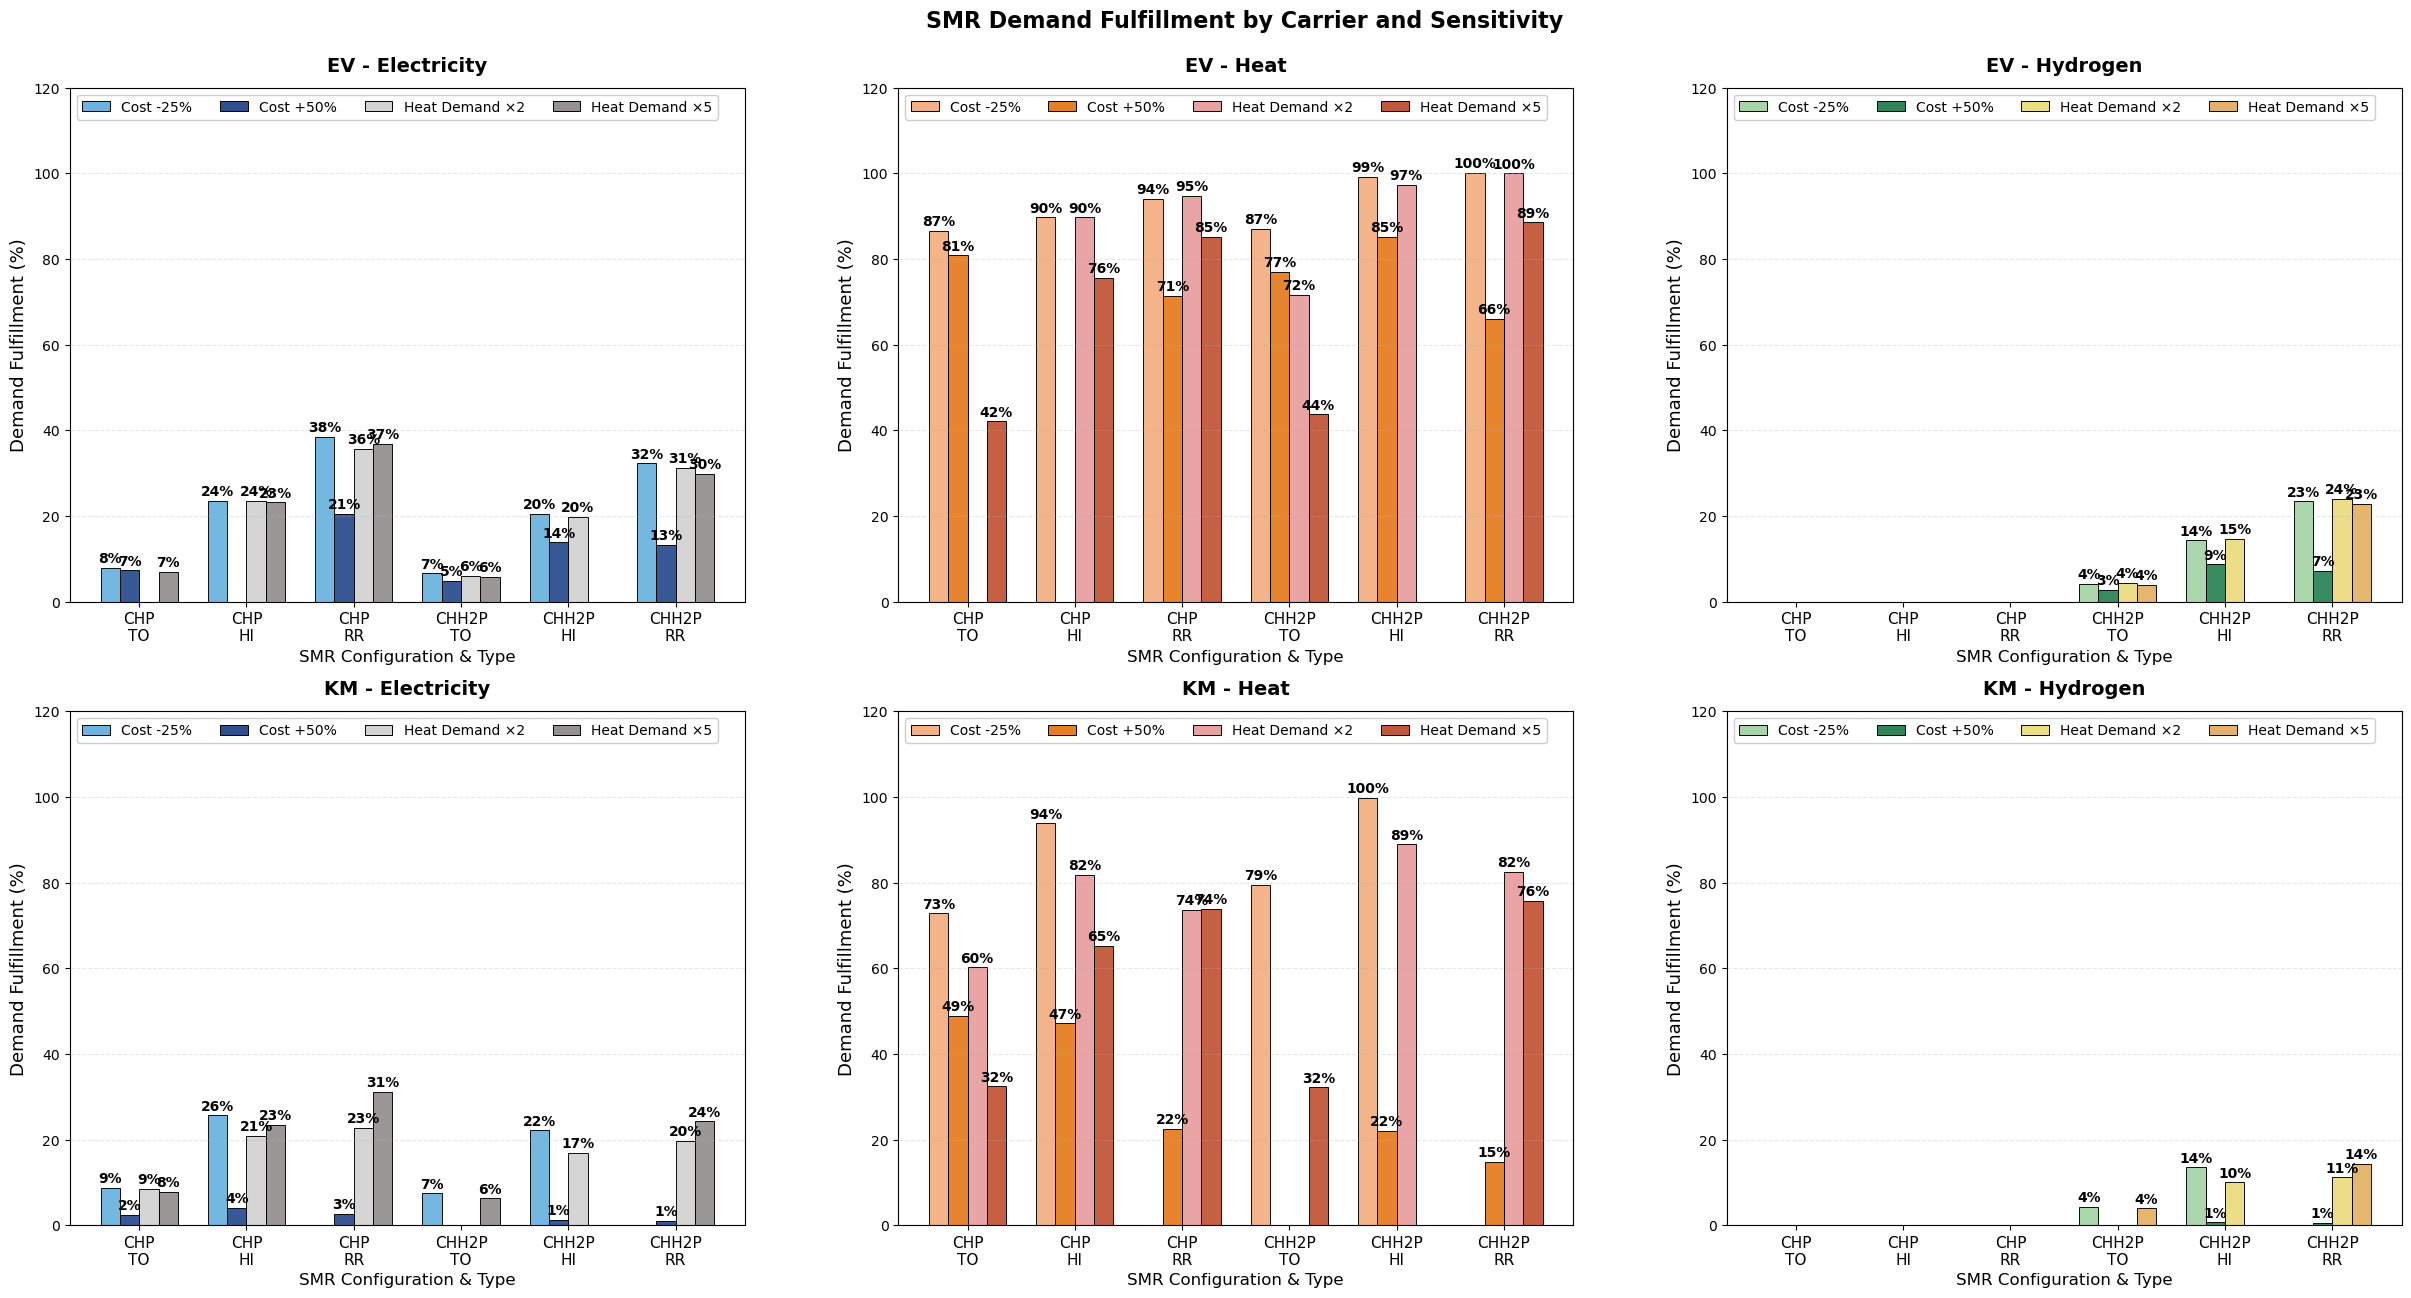

✓ VIZ1 Demand Fulfillment (6-Panel Professional Layout - Enhanced Colors) saved


In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

output_folder = Path("output/Final_Set/analysis_results_flexible")

# Load all data
data = {}
for scenario in ['EV', 'KM']:
    for sens in ['C75', 'C150', 'H2', 'H5']:
        data[f'{scenario}_{sens}'] = pd.read_csv(
            output_folder / scenario / f"viz1_demand_fulfillment_{sens}.csv"
        )

# Create 3x2 grid: columns = carriers, rows = scenarios
fig, axes = plt.subplots(2, 3, figsize=(25, 13))

carrier_names = ['Electricity', 'Heat', 'Hydrogen']
scenarios = ['EV', 'KM']

# Professional color palettes by carrier
color_palettes = {
    'Electricity': {
        'C75': '#6DB3E0',      # Light blue
        'C150': '#2E5090',     # Darker blue
        'H2': '#D3D3D3',       # Light grey
        'H5': "#969292"        # Darker grey
    },
    'Heat': {
        'C75': '#F4B084',      # Light orange
        'C150': '#E67E22',     # Darker orange
        'H2': '#E8A0A0',       # Light red
        'H5': '#C2573A'        # Darker red
    },
    'Hydrogen': {
        'C75': '#A8D5A8',      # Light green
        'C150': '#2D8659',     # Darker green
        'H2': "#ECDC82",       # Normal yellow (muted)
        'H5': "#E4B266"        # Darker yellow/orangey
    }
}

sensitivity_labels = {
    'C75': 'Cost -25%',
    'C150': 'Cost +50%',
    'H2': 'Heat Demand ×2',
    'H5': 'Heat Demand ×5'
}

for scenario_idx, scenario in enumerate(scenarios):
    for carrier_idx, carrier in enumerate(carrier_names):
        ax = axes[scenario_idx, carrier_idx]
        
        # Collect data for this scenario+carrier combination
        config_order = ['CHP', 'CHH2P']
        smr_type_order = ['TO', 'HI', 'RR']
        
        x_labels = []
        sensitivity_data = {sens: [] for sens in ['C75', 'C150', 'H2', 'H5']}
        
        for config in config_order:
            for smr_type in smr_type_order:
                x_labels.append(f"{config}\n{smr_type}")
                
                for sens in ['C75', 'C150', 'H2', 'H5']:
                    df = data[f'{scenario}_{sens}']
                    df_subset = df[(df['Config'] == config) & (df['SMR_Type'] == smr_type)]
                    
                    if not df_subset.empty:
                        if carrier == 'Electricity':
                            value = float(df_subset['Electricity_Fulfillment_%'].values[0])
                        elif carrier == 'Heat':
                            value = float(df_subset['Heat_Fulfillment_%'].values[0])
                        else:  # Hydrogen
                            value = float(df_subset['Hydrogen_Fulfillment_%'].values[0])
                        sensitivity_data[sens].append(value)
                    else:
                        sensitivity_data[sens].append(0)
        
        x = np.arange(len(x_labels))
        width = 0.18
        
        # Color palette for this carrier
        colors = color_palettes[carrier]
        
        positions = {
            'C75': x - 1.5*width,
            'C150': x - 0.5*width,
            'H2': x + 0.5*width,
            'H5': x + 1.5*width
        }
        
        for sens_idx, (sens, pos) in enumerate(positions.items()):
            color = colors[sens]
            ax.bar(pos, sensitivity_data[sens], width, 
                  label=sensitivity_labels[sens], color=color, 
                  alpha=0.95, edgecolor='black', linewidth=0.7)
        
        # Add value labels
        offset = 0.5  # vertical offset to lift label above bar
        for i, x_pos in enumerate(x):
            for sens, pos_offset in positions.items():
                value = sensitivity_data[sens][i]
                if value > 0:
                    ax.text(
                        pos_offset[i], 
                        value + offset,  # offset label upward above the bar
                        f'{value:.0f}%',
                        ha='center', 
                        va='bottom', 
                        fontsize=10, 
                        fontweight='bold'
                    )

        
        ax.set_ylabel('Demand Fulfillment (%)', fontsize=13, fontweight='light')
        ax.set_xlabel('SMR Configuration & Type', fontsize=12, fontweight='light')
        ax.set_title(f'{scenario} - {carrier}', fontsize=14, fontweight='bold', pad=12)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, fontsize=11, fontweight='light')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Set y-axis limit
        all_values = [v for vals in sensitivity_data.values() for v in vals]
        max_val = max(all_values) if all_values else 0
        ax.set_ylim(0, 120)
        
        # Legend - sensitivity names with corresponding colors
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=colors[sens], edgecolor='black', linewidth=0.7, 
                 label=sensitivity_labels[sens])
            for sens in ['C75', 'C150', 'H2', 'H5']
        ]
        ax.legend(handles=legend_elements, fontsize=10, loc='upper left', framealpha=0.95, ncol=4)


plt.suptitle('SMR Demand Fulfillment by Carrier and Sensitivity', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(output_folder / "VIZ1_demand_fulfillment_6panel.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ VIZ1 Demand Fulfillment (6-Panel Professional Layout - Enhanced Colors) saved")


In [81]:
import pandas as pd
from pathlib import Path

output_folder = Path("output/Final_Set/analysis_results_flexible")

# Define sensitivities and their locations
sensitivities = ['C75', 'C150', 'H2', 'H5']
scenarios = ['EV', 'KM']

# Load all comparison files
all_data = []

for scenario in scenarios:
    for sens in sensitivities:
        file_path = output_folder / scenario / f"comparison_{sens}.csv"
        
        try:
            df = pd.read_csv(file_path)
            
            # Add scenario and sensitivity info
            df['Scenario'] = scenario
            df['Sensitivity'] = sens
            all_data.append(df)
            print(f"✓ Loaded {file_path.name}")
        except FileNotFoundError:
            print(f"✗ File not found: {file_path}")

# Combine all data
combined_df = pd.concat(all_data, ignore_index=True)

# Create the overview table
overview_data = []

for idx, row in combined_df.iterrows():
    # Map scenario name
    scenario_name = 'Eigen Vermogen' if row['Scenario'] == 'EV' else 'Koersvaste Middenweg'
    
    # Determine configuration display (X suffix = CHH2P, no X = CHP)
    config_display = 'CHH2P' if row['Config'] == 'CHH2P' else 'CHP'
    
    # Map SMR type
    type_map = {'TO': 'Thorizon', 'HI': 'Hitachi', 'RR': 'RollsRoyce'}
    smr_type = type_map.get(row['SMR_Type'], row['SMR_Type'])
    
    # Map sensitivity label
    sensitivity_map = {
        'C75': 'Cost -25%',
        'C150': 'Cost +50%',
        'H2': 'Heat Demand ×2',
        'H5': 'Heat Demand ×5'
    }
    sensitivity_label = sensitivity_map.get(row['Sensitivity'], row['Sensitivity'])
    
    # Convert GWh to TWh (divide by 1000)
    electricity_twh = row['smr_prod_electricity_GWh'] / 1000
    heat_twh = row['smr_prod_heat_GWh'] / 1000
    hydrogen_twh = row['smr_prod_hydrogen_GWh'] / 1000
    
    overview_data.append({
        'NBNL Scenario': scenario_name,
        'Sensitivity': sensitivity_label,
        'Configuration': config_display,
        'Type': smr_type,
        'Electricity Generation [TWh]': electricity_twh,
        'Heat Generation [TWh]': heat_twh,
        'Hydrogen Generation [TWh]': hydrogen_twh
    })

overview_df = pd.DataFrame(overview_data)

# Sort for better readability: Scenario → Sensitivity → Configuration → Type
sensitivity_order = {'Cost -25%': 0, 'Cost +50%': 1, 'Heat Demand ×2': 2, 'Heat Demand ×5': 3}
config_order = {'CHP': 0, 'CHH2P': 1}
type_order = {'Thorizon': 0, 'Hitachi': 1, 'RollsRoyce': 2}

overview_df['_scenario_sort'] = overview_df['NBNL Scenario'].map({'Eigen Vermogen': 0, 'Koersvaste Middenweg': 1})
overview_df['_sensitivity_sort'] = overview_df['Sensitivity'].map(sensitivity_order)
overview_df['_config_sort'] = overview_df['Configuration'].map(config_order)
overview_df['_type_sort'] = overview_df['Type'].map(type_order)

overview_df = overview_df.sort_values(
    by=['_scenario_sort', '_sensitivity_sort', '_config_sort', '_type_sort']
).drop(columns=['_scenario_sort', '_sensitivity_sort', '_config_sort', '_type_sort']).reset_index(drop=True)

# Format numbers to 3 decimal places
for col in ['Electricity Generation [TWh]', 'Heat Generation [TWh]', 'Hydrogen Generation [TWh]']:
    overview_df[col] = overview_df[col].apply(lambda x: f'{x:.3f}')

# Display the table
print("\n" + "="*140)
print("SMR OVERVIEW TABLE - GENERATION BY CARRIER, SCENARIO, SENSITIVITY & CONFIGURATION")
print("="*140)
print(overview_df.to_string(index=False))
print("="*140)

# Save to CSV
output_file = output_folder / "SMR_Overview_Table.csv"
overview_df.to_csv(output_file, index=False)
print(f"\n✓ Table saved to {output_file}")

# Print row count
print(f"\nTotal rows: {len(overview_df)}")
print(f"Expected: 8 sensitivities × 2 scenarios × 3 SMR types × 2 configs = 96 rows")


✓ Loaded comparison_C75.csv
✓ Loaded comparison_C150.csv
✓ Loaded comparison_H2.csv
✓ Loaded comparison_H5.csv
✓ Loaded comparison_C75.csv
✓ Loaded comparison_C150.csv
✓ Loaded comparison_H2.csv
✓ Loaded comparison_H5.csv

SMR OVERVIEW TABLE - GENERATION BY CARRIER, SCENARIO, SENSITIVITY & CONFIGURATION
       NBNL Scenario    Sensitivity Configuration       Type Electricity Generation [TWh] Heat Generation [TWh] Hydrogen Generation [TWh]
      Eigen Vermogen      Cost -25%           CHP   Thorizon                       25.656                 4.989                     0.000
      Eigen Vermogen      Cost -25%           CHP    Hitachi                       76.424                 5.170                     0.000
      Eigen Vermogen      Cost -25%           CHP RollsRoyce                      124.696                 5.415                     0.000
      Eigen Vermogen      Cost -25%         CHH2P   Thorizon                       21.557                 5.342                     1.528
     